# Task 4: Double Down Analysis

This analysis explores the "Double Down" ability. We evaluate:
1. Which categories are chosen most frequently for a double down?
2. Which levels are chosen most frequently for a double down?
3. How does the number of active skills affect the decision to double down?
4. How do these factors differ between `Control` runs and `Tool` runs?
5. How does the `Tool` mode's double down selection compare against its overall baseline distribution?

Loaded 11 Double Down events.


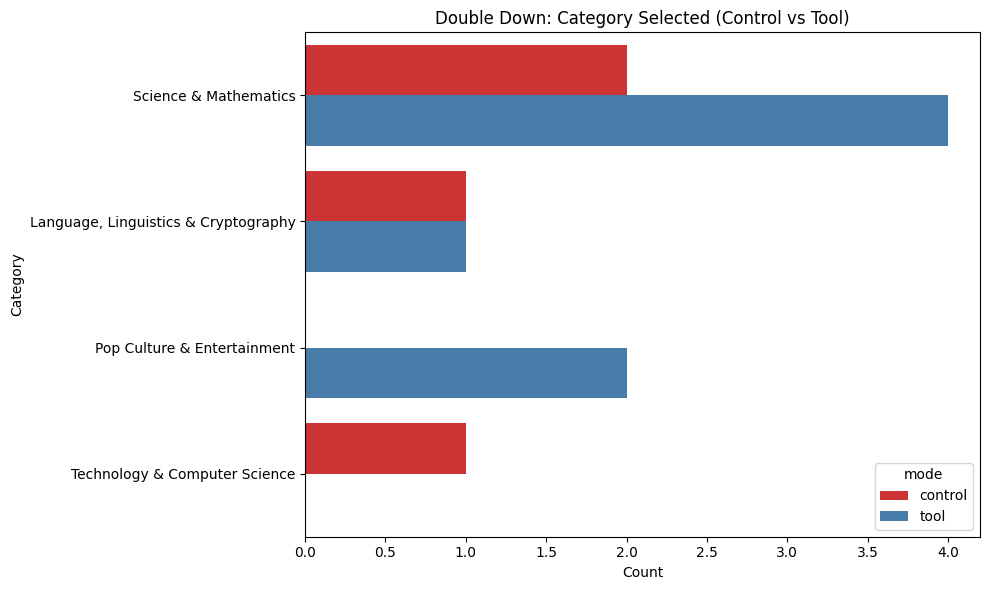

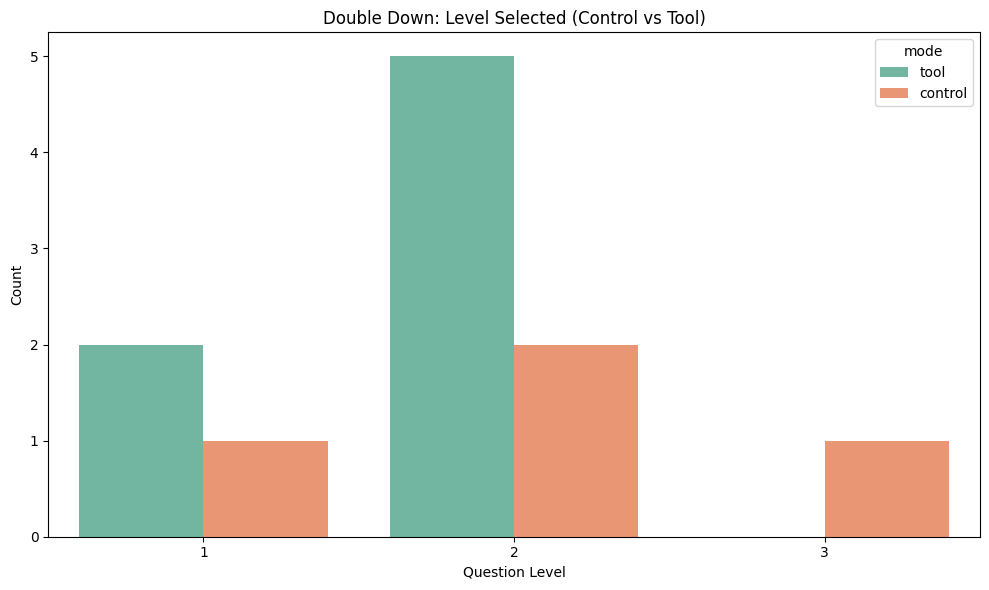

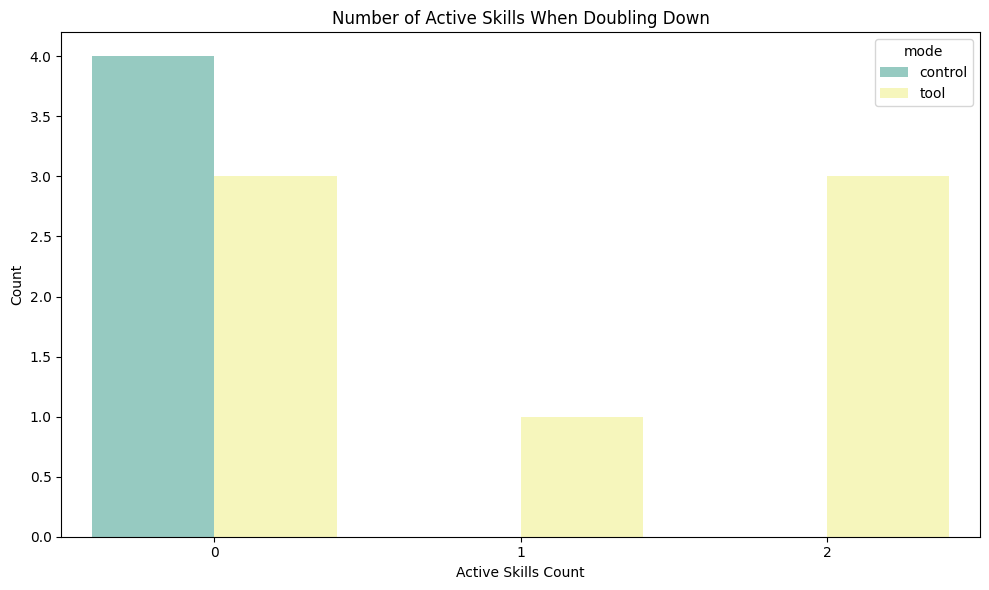

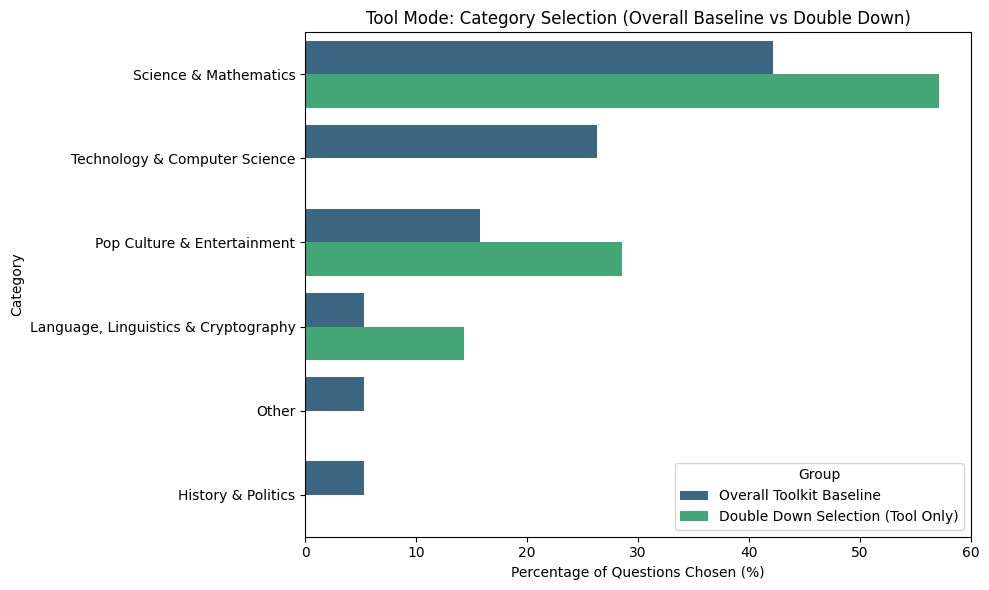

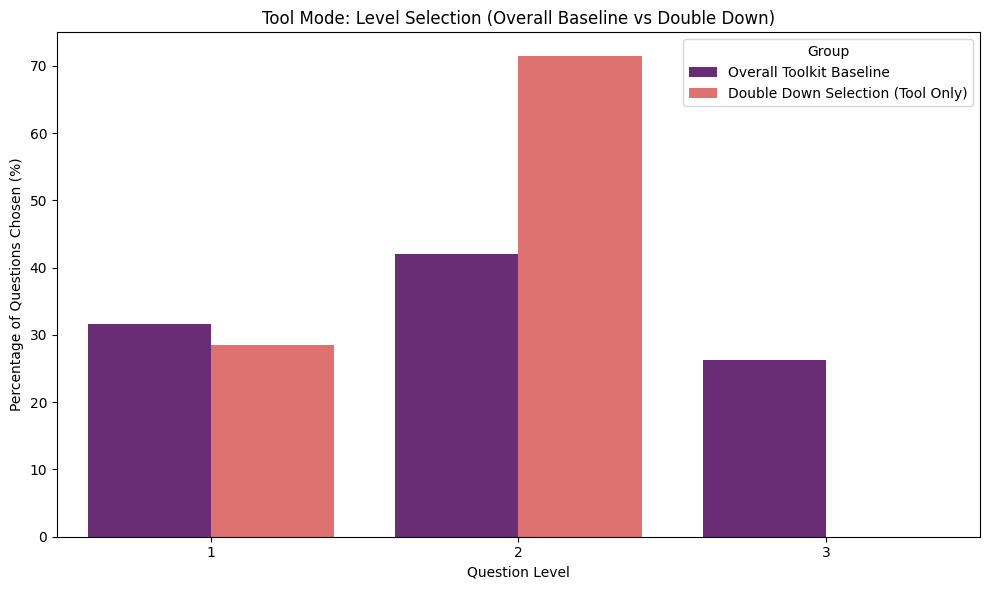

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load Double Down data
with open('../scripts/parsed_task4.json', 'r') as f:
    dd_data = json.load(f)
df_dd = pd.DataFrame(dd_data)

if df_dd.empty:
    print("No double down actions found.")
else:
    print(f"Loaded {len(df_dd)} Double Down events.")
    
    # Load Overall Baseline data
    with open('../scripts/parsed_data.json', 'r') as f:
        all_data = json.load(f)
        
    all_tool_categories = []
    all_tool_levels = []
    for r in all_data:
        if r['mode'] == 'tool':
            for q in r['questions_attempted']:
                all_tool_categories.append(q['category'])
                all_tool_levels.append(int(q['level']))
                
    # ==========================================================
    # 1. Compare Control vs Tool: Double Down CATEGORY
    # ==========================================================
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_dd, y='category', hue='mode', palette='Set1')
    plt.title('Double Down: Category Selected (Control vs Tool)')
    plt.xlabel('Count')
    plt.ylabel('Category')
    plt.tight_layout()
    plt.show()

    # ==========================================================
    # 2. Compare Control vs Tool: Double Down LEVEL
    # ==========================================================
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_dd, x='level', hue='mode', palette='Set2')
    plt.title('Double Down: Level Selected (Control vs Tool)')
    plt.xlabel('Question Level')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # ==========================================================
    # 3. Active Skills Count During Double Down (Control vs Tool)
    # ==========================================================
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_dd, x='active_skills_count', hue='mode', palette='Set3')
    plt.title('Number of Active Skills When Doubling Down')
    plt.xlabel('Active Skills Count')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # ==========================================================
    # 4. Tool Mode: Double Down vs Overall Baseline - CATEGORY
    # ==========================================================
    # Baseline Category
    df_overall_cat = pd.DataFrame(all_tool_categories, columns=['category'])
    overall_cat_counts = df_overall_cat['category'].value_counts(normalize=True).reset_index()
    overall_cat_counts.columns = ['Category', 'Percentage']
    overall_cat_counts['Group'] = 'Overall Toolkit Baseline'

    # Tool Double Down Category
    df_dd_tool = df_dd[df_dd['mode'] == 'tool']
    dd_cat_counts = df_dd_tool['category'].value_counts(normalize=True).reset_index()
    dd_cat_counts.columns = ['Category', 'Percentage']
    dd_cat_counts['Group'] = 'Double Down Selection (Tool Only)'

    combined_cat = pd.concat([overall_cat_counts, dd_cat_counts])
    combined_cat['Percentage'] *= 100

    plt.figure(figsize=(10, 6))
    sns.barplot(data=combined_cat, y='Category', x='Percentage', hue='Group', palette='viridis')
    plt.title('Tool Mode: Category Selection (Overall Baseline vs Double Down)')
    plt.xlabel('Percentage of Questions Chosen (%)')
    plt.ylabel('Category')
    plt.tight_layout()
    plt.show()

    # ==========================================================
    # 5. Tool Mode: Double Down vs Overall Baseline - LEVEL
    # ==========================================================
    # Baseline Level
    df_overall_lvl = pd.DataFrame(all_tool_levels, columns=['level'])
    overall_lvl_counts = df_overall_lvl['level'].value_counts(normalize=True).reset_index()
    overall_lvl_counts.columns = ['Level', 'Percentage']
    overall_lvl_counts['Group'] = 'Overall Toolkit Baseline'

    # Tool Double Down Level
    dd_lvl_counts = df_dd_tool['level'].value_counts(normalize=True).reset_index()
    dd_lvl_counts.columns = ['Level', 'Percentage']
    dd_lvl_counts['Group'] = 'Double Down Selection (Tool Only)'

    combined_lvl = pd.concat([overall_lvl_counts, dd_lvl_counts])
    combined_lvl['Percentage'] *= 100

    plt.figure(figsize=(10, 6))
    sns.barplot(data=combined_lvl, x='Level', y='Percentage', hue='Group', palette='magma')
    plt.title('Tool Mode: Level Selection (Overall Baseline vs Double Down)')
    plt.ylabel('Percentage of Questions Chosen (%)')
    plt.xlabel('Question Level')
    plt.tight_layout()
    plt.show()